# 📌 Table of Contents

1. **[Introduction to Financial Leading Indicators](#1-introduction-to-financial-leading-indicators)**
2. **[Theoretical Foundations](#2-theoretical-foundations)**
   - [Granger Causality](#21-granger-causality)
   - [SARIMAX Models](#22-sarimax-models)
3. **[Setup & Data Loading](#3-setup--data-loading)**
4. **[Data Exploration & Visualization](#4-data-exploration--visualization)**
5. **[Stationarity Testing](#5-stationarity-testing)**
6. **[Granger Causality Analysis](#6-granger-causality-analysis)**
7. **[Preprocessing for Modeling](#7-preprocessing-for-modeling)**
8. **[SARIMAX Model Building](#8-sarimax-model-building)**
9. **[Model Evaluation](#9-model-evaluation)**
10. **[Conclusion & Next Steps](#10-conclusion--next-steps)**


In [1]:
# Check Python version and install required packages
!python --version
!pip install yfinance pmdarima statsmodels matplotlib seaborn pandas numpy scikit-learn


Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.1 MB/s eta 0:00:00


In [3]:
# Import all necessary libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pandas.tseries.offsets import MonthEnd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
import yfinance as yf

%matplotlib inline


---

## 1. Introduction to Financial Leading Indicators

In financial markets, **leading indicators** are variables that provide early signals about future market movements. Unlike lagging indicators that confirm past trends, leading indicators help predict where the market is heading.

### 🔍 Real-World Examples in Finance

| Leading Indicator | What It Predicts | Reason |
|-------------------|------------------|--------|
| Consumer Discretionary Sector (XLY) | Overall Market (SPY) | Consumer spending drives ~70% of US GDP |
| Technology Sector (XLK) | Market Performance | Tech innovation drives productivity growth |
| Interest Rate Spreads | Economic Growth | Inverted yield curves predict recessions |
| Building Permits | Construction Sector | Leading indicator for economic activity |
| Manufacturing PMI | Industrial Production | PMI > 50 indicates expansion |

### 📊 In Our Analysis

We'll forecast **SPY (S&P 500 ETF)** using potential leading indicators from major sector ETFs:

- **XLY**: Consumer Discretionary (consumer spending)
- **XLP**: Consumer Staples (defensive sector)
- **XLE**: Energy Sector (commodity prices)
- **XLK**: Technology Sector (innovation)
- **XLF**: Financials (banking sector)
- **XLV**: Healthcare Sector (defensive growth)

### 💡 Why These Work as Leading Indicators

- Different sectors lead or lag the broader market
- Consumer discretionary often leads because it reflects consumer confidence
- Technology leads due to its high beta and growth orientation
- Financials lead due to interest rate sensitivity

---

## 2. Theoretical Foundations

---

### 2.1 Granger Causality in Financial Markets

**Definition**: A statistical hypothesis test to determine if one financial time series can predict another.

#### Mathematical Formulation

Given two stationary financial time series $X_t$ (e.g., XLY) and $Y_t$ (e.g., SPY), we say $X_t$ Granger-causes $Y_t$ if:

$$
Y_t = \alpha + \sum_{i=1}^{p} \beta_i Y_{t-i} + \sum_{j=1}^{q} \gamma_j X_{t-j} + \epsilon_t
$$

has better predictive power (lower error) than:

$$
Y_t = \alpha + \sum_{i=1}^{p} \beta_i Y_{t-i} + \epsilon_t
$$

#### Key Points for Financial Data

- ❌ **Not true causality** in the philosophical sense
- ✅ **Predictive relationship**: X provides information about future Y
- 📊 **Test statistic**: F-test on lagged values
- 🚫 **Null Hypothesis (H₀)**: X does NOT Granger-cause Y
- ✅ **Reject H₀** if p-value < significance level (typically 0.05)

---

### 2.2 SARIMAX Models for Financial Time Series

**SARIMAX** stands for:

- **Seasonal**: Captures regular patterns (monthly, quarterly)
- **AutoRegressive**: Uses past values to predict future values
- **Integrated**: Differencing to make series stationary
- **Moving Average**: Uses past forecast errors
- **Xogenous**: Incorporates external variables

#### Why SARIMAX for Financial Data?

- ✅ Captures autocorrelation in returns
- ✅ Handles seasonality (monthly, quarterly patterns)
- ✅ Incorporates exogenous variables (our leading indicators)
- ✅ Provides confidence intervals for risk management

#### Mathematical Representation

$$
\phi_p(B)\Phi_P(B^s)\nabla^d \nabla_s^D Y_t = \theta_q(B)\Theta_Q(B^s)\epsilon_t + \beta X_t
$$

Where:

- $B$ is the backshift operator
- $\phi_p(B)$ is the non-seasonal AR polynomial
- $\Phi_P(B^s)$ is the seasonal AR polynomial
- $\nabla^d$ is differencing of order d
- $X_t$ are exogenous variables (sector ETFs)
- $\beta$ are coefficients for exogenous variables


# 3. Setup & Data Loading

# 3.1 Yahoo Finance Data Loading

In [6]:
# Define our target time series (S&P 500 ETF)
target_ticker = 'SPY'
target_name = 'spy_price'

# Define potential leading indicators (major sector ETFs)
sector_etfs = {
    'XLY': 'consumer_discretionary',
    'XLP': 'consumer_staples',
    'XLE': 'energy',
    'XLK': 'technology',
    'XLF': 'financials',
    'XLV': 'healthcare'
}

# Define date range (last 10 years)
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=365*10)).strftime('%Y-%m-%d')

print(f"Loading data from {start_date} to {end_date}...")

# Load target data
print(f"Loading {target_ticker}...")
target_data = yf.download(target_ticker, start=start_date, end=end_date)
timeseries = pd.DataFrame({
    target_name: target_data['Adj Close']
})

# Load sector ETF data
for ticker, name in sector_etfs.items():
    print(f"Loading {ticker} ({name})...")
    sector_data = yf.download(ticker, start=start_date, end=end_date)
    timeseries[name] = sector_data['Close']

# Resample to monthly frequency (end of month)
timeseries = timeseries.resample('M').last().dropna()

# Add one more month for prediction (as shown in original article)
last_date = timeseries.index[-1]
next_month = last_date + pd.DateOffset(months=1)
timeseries = timeseries.reindex(timeseries.index.union([next_month]))

print(f"\n✅ Data loaded successfully! Shape: {timeseries.shape}")
print(f"📅 Time range: {timeseries.index.min()} to {timeseries.index.max()}")
print(f"\n📊 Available columns: {list(timeseries.columns)}")

timeseries.head()


[*********************100%***********************]  1 of 1 completed

Loading data from 2016-06-17 to 2026-06-15...
Loading SPY...
Loading XLY (consumer_discretionary)...



[*********************100%***********************]  1 of 1 completed


Loading XLP (consumer_staples)...


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


Loading XLV (healthcare)...


[*********************100%***********************]  1 of 1 completed


✅ Data loaded successfully! Shape: (122, 7)
📅 Time range: 2016-06-30 00:00:00 to 2026-07-30 00:00:00

📊 Available columns: ['spy_price', 'consumer_discretionary', 'consumer_staples', 'energy', 'technology', 'financials', 'healthcare']


,spy_price,consumer_discretionary,consumer_staples,energy,technology,financials,healthcare
Date,,,,,,,
2016-06-30,178.897507,35.245792,42.459164,22.894442,19.543772,15.486409,60.924881
2016-07-31,185.422134,36.853207,42.112709,22.605917,20.931711,16.021597,63.889988
2016-08-31,185.644150,36.374592,41.866337,22.985035,21.175055,16.638073,61.816967
2016-09-30,185.654999,36.277592,41.219296,23.832764,21.620108,16.171911,61.501942
2016-10-31,182.436218,35.398300,40.901684,23.161095,21.457214,16.540598,57.450691


# 4. Data Exploration & Visualization

# 4.1 Basic Data Overview

In [7]:
# Display summary statistics
print("=== Summary Statistics ===")
print(timeseries.describe())

# Calculate monthly returns for better analysis
returns_df = timeseries.pct_change().dropna() * 100  # Convert to percentage
print("\n=== Monthly Returns Statistics ===")
print(returns_df.describe())

# Check for missing values
print("\n=== Missing Values ===")
print(timeseries.isnull().sum())


=== Summary Statistics ===
        spy_price  consumer_discretionary  consumer_staples      energy  \
count  121.000000              121.000000        121.000000  121.000000   
mean   380.434463               73.056481         59.883888   30.618379   
std    152.409534               24.855323         14.027724   11.292042   
min    178.897507               35.245792         39.181950   11.454534   
25%    248.118774               51.541401         45.595085   22.616156   
50%    368.546753               72.331665         61.121761   26.057671   
75%    462.579987               89.348892         70.293228   40.078167   
max    756.479980              120.927078         89.506195   61.259998   

       technology  financials  healthcare  
count  121.000000  121.000000  121.000000  
mean    68.496484   31.808476  107.007428  
std     39.374846   10.969831   29.793082  
min     19.543772   15.486409   57.450691  
25%     33.170303   22.928085   80.105957  
50%     62.764923   30.630672  11

# 4.2 Visualizing SPY Price Trend

plt.figure(figsize=(15, 6))
timeseries[target_name].plot(label='SPY Price', linewidth=2.5)
plt.title('Monthly SPY Price (S&P 500 ETF) - Last 10 Years', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


# 4.3 Visualizing Sector ETFs

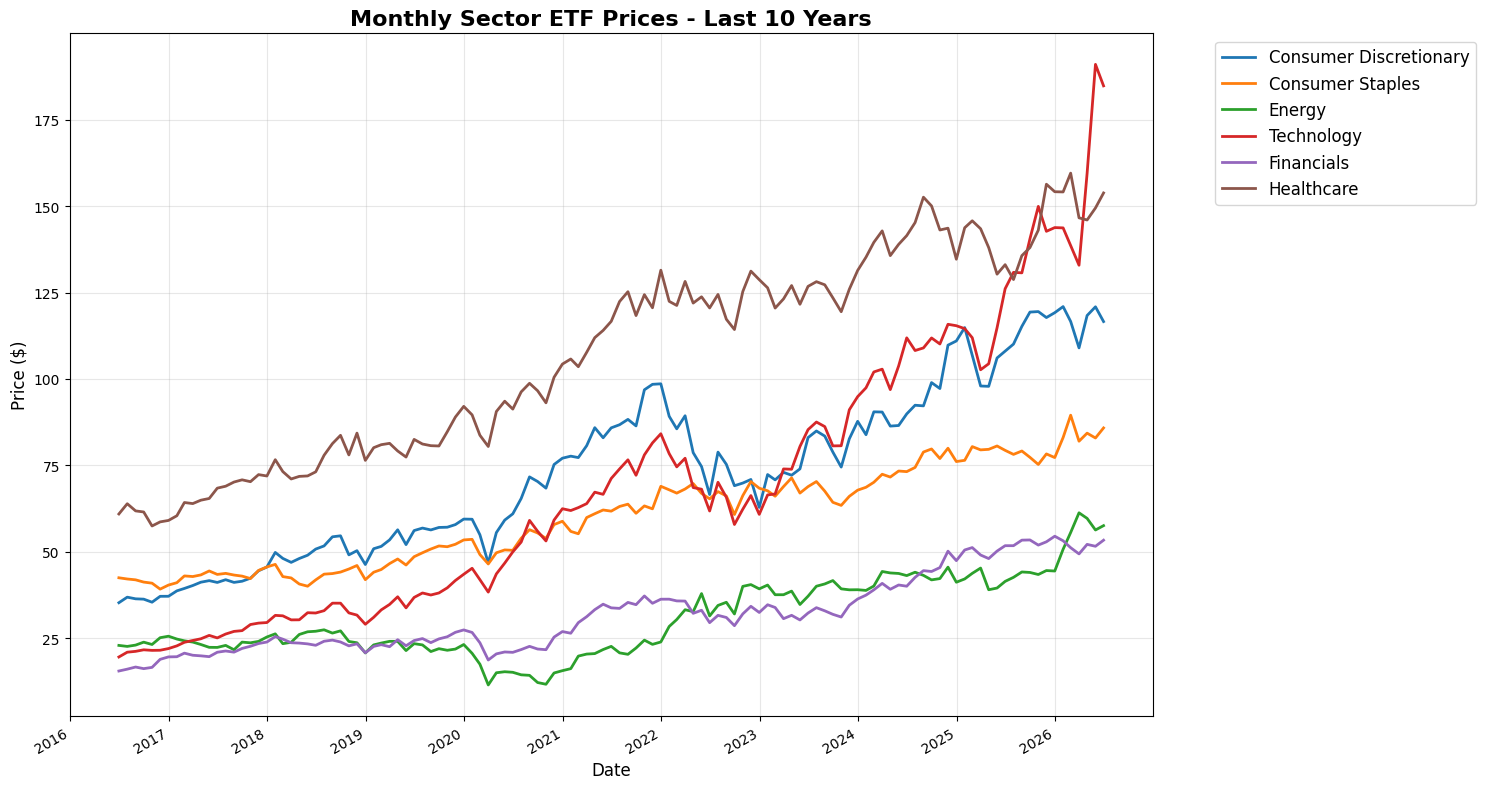

In [8]:
plt.figure(figsize=(15, 8))
for col in sector_etfs.values():
    timeseries[col].plot(label=col.replace('_', ' ').title(), linewidth=2)

plt.title('Monthly Sector ETF Prices - Last 10 Years', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 4.4 Normalized Comparison (Indexed to 100)



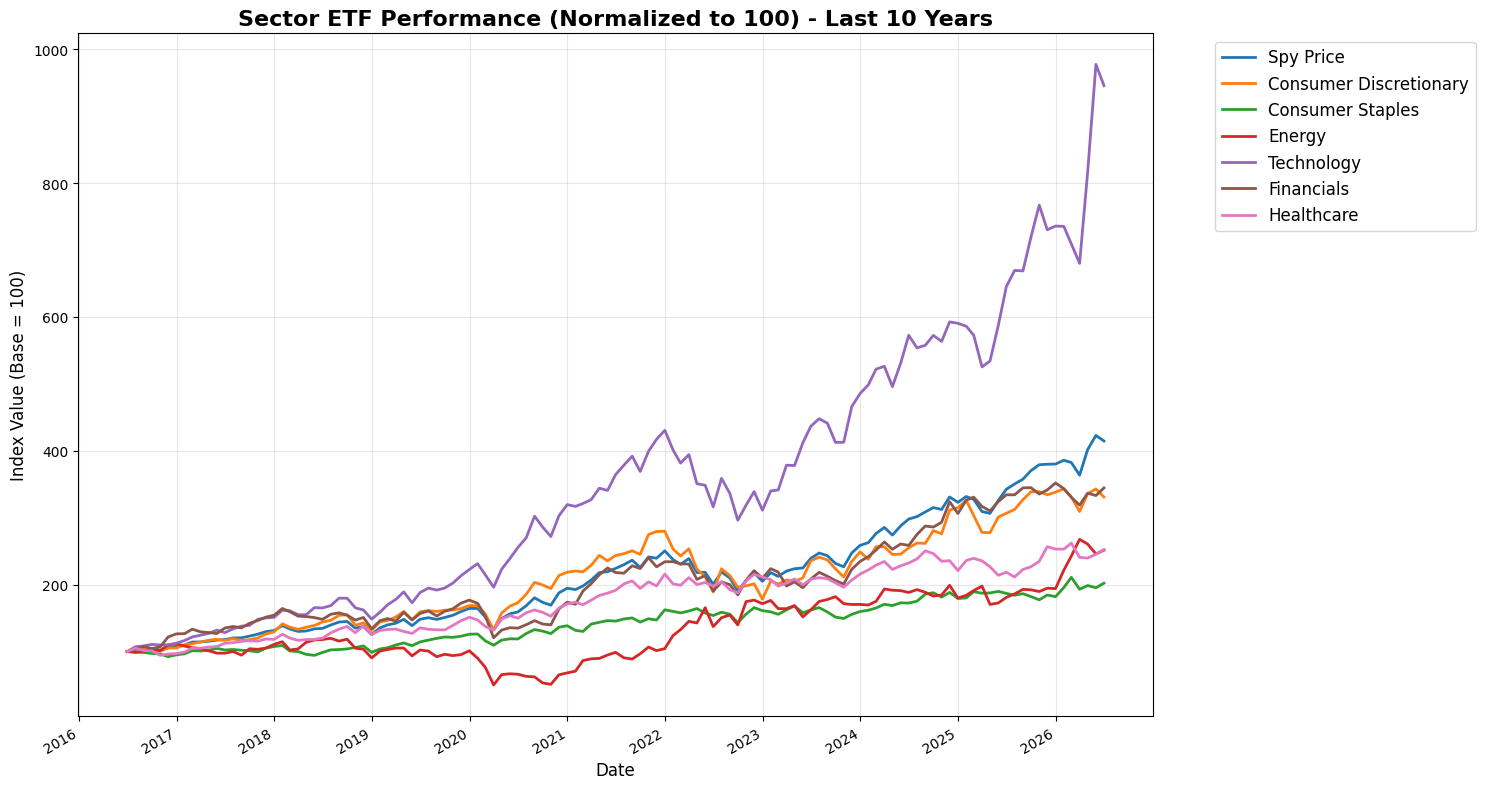

In [10]:
# Create normalized comparison
normalized = timeseries.copy()
for col in normalized.columns:
    normalized[col] = normalized[col] / normalized[col].iloc[0] * 100

plt.figure(figsize=(15, 8))
for col in normalized.columns:
    normalized[col].plot(label=col.replace('_', ' ').title(), linewidth=2)

plt.title('Sector ETF Performance (Normalized to 100) - Last 10 Years', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index Value (Base = 100)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 4.5 Correlation Analysis

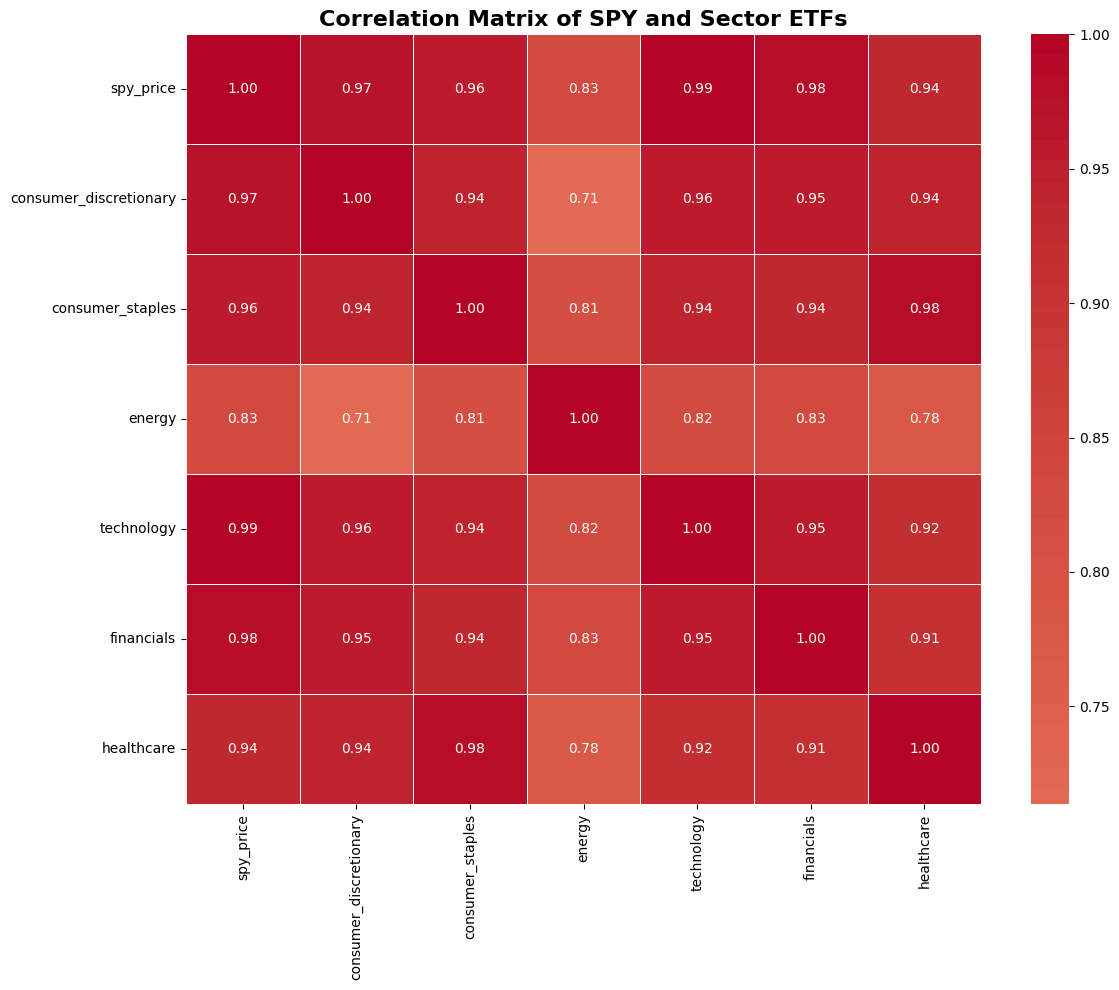

In [12]:
# Calculate correlation matrix
corr_matrix = timeseries.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    annot_kws={'size': 10},
    linewidths=0.5
)
plt.title('Correlation Matrix of SPY and Sector ETFs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# 5. Stationarity Testing

# 5.1 Understanding Returns vs Prices

# Financial time series are typically non-stationary in levels but stationary in returns. Let's test both:

In [13]:
print("=== Testing Stationarity ===\n")

# Test prices (likely non-stationary)
print("📈 Testing Price Levels:")
for col in timeseries.columns:
    result = adfuller(timeseries[col].dropna())
    print(f"{col}: p-value = {result[1]:.4f} {'✅ Stationary' if result[1] < 0.05 else '❌ Non-stationary'}")

print("\n📊 Testing Monthly Returns:")
for col in returns_df.columns:
    result = adfuller(returns_df[col].dropna())
    print(f"{col}: p-value = {result[1]:.4f} {'✅ Stationary' if result[1] < 0.05 else '❌ Non-stationary'}")


=== Testing Stationarity ===

📈 Testing Price Levels:
spy_price: p-value = 0.9980 ❌ Non-stationary
consumer_discretionary: p-value = 0.8293 ❌ Non-stationary
consumer_staples: p-value = 0.9657 ❌ Non-stationary
energy: p-value = 0.9642 ❌ Non-stationary
technology: p-value = 0.9974 ❌ Non-stationary
financials: p-value = 0.9210 ❌ Non-stationary
healthcare: p-value = 0.8507 ❌ Non-stationary

📊 Testing Monthly Returns:
spy_price: p-value = 0.0000 ✅ Stationary
consumer_discretionary: p-value = 0.0000 ✅ Stationary
consumer_staples: p-value = 0.0000 ✅ Stationary
energy: p-value = 0.0000 ✅ Stationary
technology: p-value = 0.0000 ✅ Stationary
financials: p-value = 0.0000 ✅ Stationary
healthcare: p-value = 0.0000 ✅ Stationary


# 5.2 Using Returns for Modeling

# Since returns are stationary and more relevant for forecasting, we'll work with returns instead of prices:

In [14]:
# Create a returns dataframe for our analysis
returns_df = timeseries.pct_change().dropna() * 100  # Convert to percentage
returns_df.index = timeseries.index[1:]  # Align index

# Add one more month for prediction
last_date = returns_df.index[-1]
next_month = last_date + pd.DateOffset(months=1)
returns_df = returns_df.reindex(returns_df.index.union([next_month]))

print(f"Returns dataframe shape: {returns_df.shape}")
print("Returns dataframe head:")
returns_df.head()


Returns dataframe shape: (122, 7)
Returns dataframe head:


,spy_price,consumer_discretionary,consumer_staples,energy,technology,financials,healthcare
Date,,,,,,,
2016-07-31,3.647132,4.560585,-0.815971,-1.260239,7.101697,3.455854,4.866824
2016-08-31,0.119735,-1.298706,-0.585031,1.677074,1.162558,3.847782,-3.244673
2016-09-30,0.005844,-0.266670,-1.545493,3.688177,2.101780,-2.801777,-0.509610
2016-10-31,-1.733743,-2.423787,-0.770541,-2.818259,-0.753434,2.279797,-6.587191
2016-11-30,3.683856,4.801566,-4.204556,8.466877,0.168715,14.032412,2.063577


# 6. Granger Causality Analysis

# 6.1 Understanding the Test Parameters

In [15]:
# Parameters for Granger Causality test
maxlag = 6  # Maximum number of lags to test (6 months)
significance_level = 0.05

print(f"Testing Granger Causality with max lag = {maxlag} months")
print(f"Significance level: {significance_level}\n")
print("Target variable: SPY returns")


Testing Granger Causality with max lag = 6 months
Significance level: 0.05

Target variable: SPY returns


# 6.2 Performing the Test on Returns



# 6.3 Visualizing Granger Causality Results

# 7. Preprocessing for Modeling

# 7.1 Selecting Final Leading Indicators

Performing Granger Causality tests on monthly returns...

Testing: Consumer Discretionary → SPY Returns
  ❌ No significant Granger causality found

Testing: Consumer Staples → SPY Returns
  ✅ Significant at lag 2 months (p=0.0426)
  ✅ Significant at lag 6 months (p=0.0062)
  → Selected as leading indicator with lag 2 months

Testing: Energy → SPY Returns
  ❌ No significant Granger causality found

Testing: Technology → SPY Returns
  ❌ No significant Granger causality found

Testing: Financials → SPY Returns
  ❌ No significant Granger causality found

Testing: Healthcare → SPY Returns
  ❌ No significant Granger causality found


=== Leading Indicators Identified ===


,variable,lag,p_value,f_statistic
0,consumer_staples,2,0.042649,3.243683


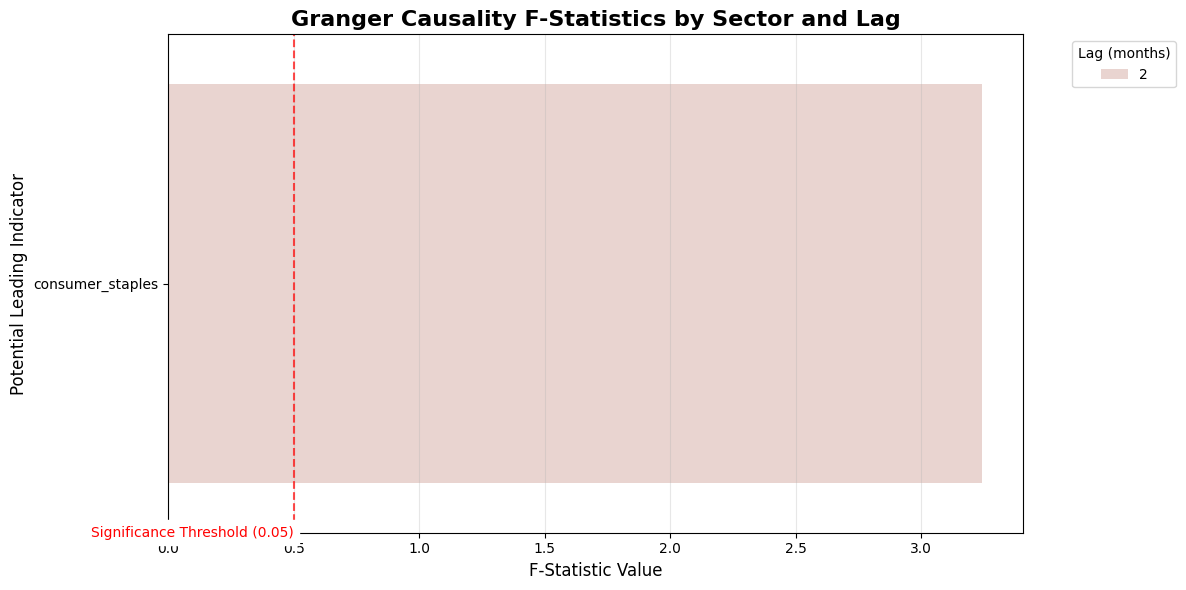

Selected leading indicators: ['consumer_staples']

Exogenous variables shape: (118, 4)


In [17]:
# Initialize list to store leading indicators
leading_indicators = []

print("Performing Granger Causality tests on monthly returns...\n")

# Ensure we're working with clean data - drop any rows with NaN values
clean_returns_df = returns_df.dropna()

for x in sector_etfs.values():  # Skip the target variable
    print(f"Testing: {x.replace('_', ' ').title()} → SPY Returns")

    # Perform Granger Causality test on clean data
    gc_res = grangercausalitytests(
        clean_returns_df[['spy_price', x]],
        maxlag=maxlag,
        verbose=False  # Set to True for detailed output
    )

    # Collect significant lags
    leading_indicators_tmp = []
    for lag in range(1, maxlag + 1):
        ftest_stat = gc_res[lag][0]['ssr_ftest'][0]
        ftest_pvalue = gc_res[lag][0]['ssr_ftest'][1]

        if ftest_pvalue <= significance_level:
            leading_indicators_tmp.append({
                'variable': x,
                'lag': lag,
                'p_value': ftest_pvalue,
                'f_statistic': ftest_stat,
                'label': f'{x}__{lag}mths'
            })
            print(f"  ✅ Significant at lag {lag} months (p={ftest_pvalue:.4f})")

    # Keep the strongest indicator (highest F-statistic)
    if leading_indicators_tmp:
        best_indicator = max(leading_indicators_tmp, key=lambda x: x['f_statistic'])
        leading_indicators.append(best_indicator)
        print(f"  → Selected as leading indicator with lag {best_indicator['lag']} months\n")
    else:
        print(f"  ❌ No significant Granger causality found\n")

# Display results as a DataFrame
if leading_indicators:
    leading_df = pd.DataFrame(leading_indicators)
    leading_df = leading_df.sort_values('f_statistic', ascending=False)
    print("\n=== Leading Indicators Identified ===")
    display(leading_df[['variable', 'lag', 'p_value', 'f_statistic']])
else:
    print("\nNo leading indicators found with the given parameters.")

if leading_indicators:
    plt.figure(figsize=(12, 6))

    # Create a bar plot of F-statistics
    sns.barplot(
        data=leading_df,
        x='f_statistic',
        y='variable',
        hue='lag',
        dodge=False
    )

    plt.axvline(x=significance_level * 10, color='red', linestyle='--', alpha=0.7)
    plt.text(
        significance_level * 10, 0.5,
        f'Significance Threshold ({significance_level})',
        color='red',
        va='center',
        ha='right',
        backgroundcolor='white'
    )

    plt.title('Granger Causality F-Statistics by Sector and Lag', fontsize=16, fontweight='bold')
    plt.xlabel('F-Statistic Value', fontsize=12)
    plt.ylabel('Potential Leading Indicator', fontsize=12)
    plt.grid(True, alpha=0.3, axis='x')
    plt.legend(title='Lag (months)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Based on our analysis, select the top indicators
if leading_indicators:
    # Get variable names only (without lags)
    selected_vars = [ind['variable'] for ind in leading_indicators[:3]]  # Top 3
    print(f"Selected leading indicators: {selected_vars}")

    # Create exogenous variables dataframe
    exogenous_vars = clean_returns_df[selected_vars].copy()

    # Add lagged versions of the target variable (SPY returns)
    for lag in [1, 2, 3]:
        exogenous_vars[f'spy_return_lag_{lag}'] = clean_returns_df['spy_price'].shift(lag)

    # Drop rows with missing values
    exogenous_vars = exogenous_vars.dropna()
    print(f"\nExogenous variables shape: {exogenous_vars.shape}")
    exogenous_vars.head()
else:
    print("No leading indicators found. Using only lagged returns.")
    # Fallback: use lagged dependent variable


# 7.2 Standard Scaling

In [18]:
# Standardize the exogenous variables
scaler = StandardScaler()
exogenous_scaled = pd.DataFrame(
    scaler.fit_transform(exogenous_vars),
    columns=exogenous_vars.columns,
    index=exogenous_vars.index
)

print("Exogenous variables after scaling:")
exogenous_scaled.head()


Exogenous variables after scaling:


,consumer_staples,spy_return_lag_1,spy_return_lag_2,spy_return_lag_3
Date,,,,
2016-10-31,-0.386481,-0.286636,-0.265472,0.533978
2016-11-30,-1.291906,-0.678028,-0.291147,-0.262965
2016-12-31,0.606769,0.540883,-0.683305,-0.288697
2017-01-31,0.265385,0.168148,0.537994,-0.681721
2017-02-28,1.075084,0.114668,0.164528,0.542275


# 7.3 Checking for Multicollinearity

In [19]:
# Calculate Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add constant for VIF calculation
X_vif = exogenous_scaled.copy()
X_vif['const'] = 1

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Variance Inflation Factors:")
display(vif_data.sort_values('VIF', ascending=False))

# High VIF (>5-10) indicates multicollinearity
high_vif = vif_data[vif_data['VIF'] > 5]['feature'].tolist()
print(f"\nFeatures with high multicollinearity (VIF > 5): {high_vif}")


Variance Inflation Factors:


,feature,VIF
2,spy_return_lag_2,1.060688
1,spy_return_lag_1,1.058651
3,spy_return_lag_3,1.049591
0,consumer_staples,1.018054
4,const,1.000000



Features with high multicollinearity (VIF > 5): []


# 8. SARIMAX Model Building

# 8.1 Understanding auto_arima Parameters

In [20]:
# Display auto_arima documentation for reference
help(auto_arima)


Help on function auto_arima in module pmdarima.arima.auto:

auto_arima(y, X=None, start_p=2, d=None, start_q=2, max_p=5, max_d=2, max_q=5, start_P=1, D=None, start_Q=1, max_P=2, max_D=1, max_Q=2, max_order=5, m=1, seasonal=True, stationary=False, information_criterion='aic', alpha=0.05, test='kpss', seasonal_test='ocsb', stepwise=True, n_jobs=1, start_params=None, trend=None, method='lbfgs', maxiter=50, offset_test_args=None, seasonal_test_args=None, suppress_warnings=True, error_action='trace', trace=False, random=False, random_state=None, n_fits=10, return_valid_fits=False, out_of_sample_size=0, scoring='mse', scoring_args=None, with_intercept='auto', sarimax_kwargs=None, **fit_args)
    Automatically discover the optimal order for an ARIMA model.

    The auto-ARIMA process seeks to identify the most optimal
    parameters for an ``ARIMA`` model, settling on a single fitted ARIMA model.
    This process is based on the commonly-used R function,
    ``forecast::auto.arima`` [3].

   

# 8.2 Building the SARIMAX Model

Training set size: 97 months
Test set size: 25 months
Target variable range: -12.49% to 12.70%
Exogenous variables shape - Train: (97, 4), Test: (25, 4)

Building SARIMAX model with auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=580.465, Time=3.49 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=574.285, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=575.703, Time=0.40 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=574.714, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=579.264, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=576.285, Time=0.04 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=576.285, Time=0.03 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=573.741, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=575.708, Time=0.06 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=577.336, Time=0.19 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : 

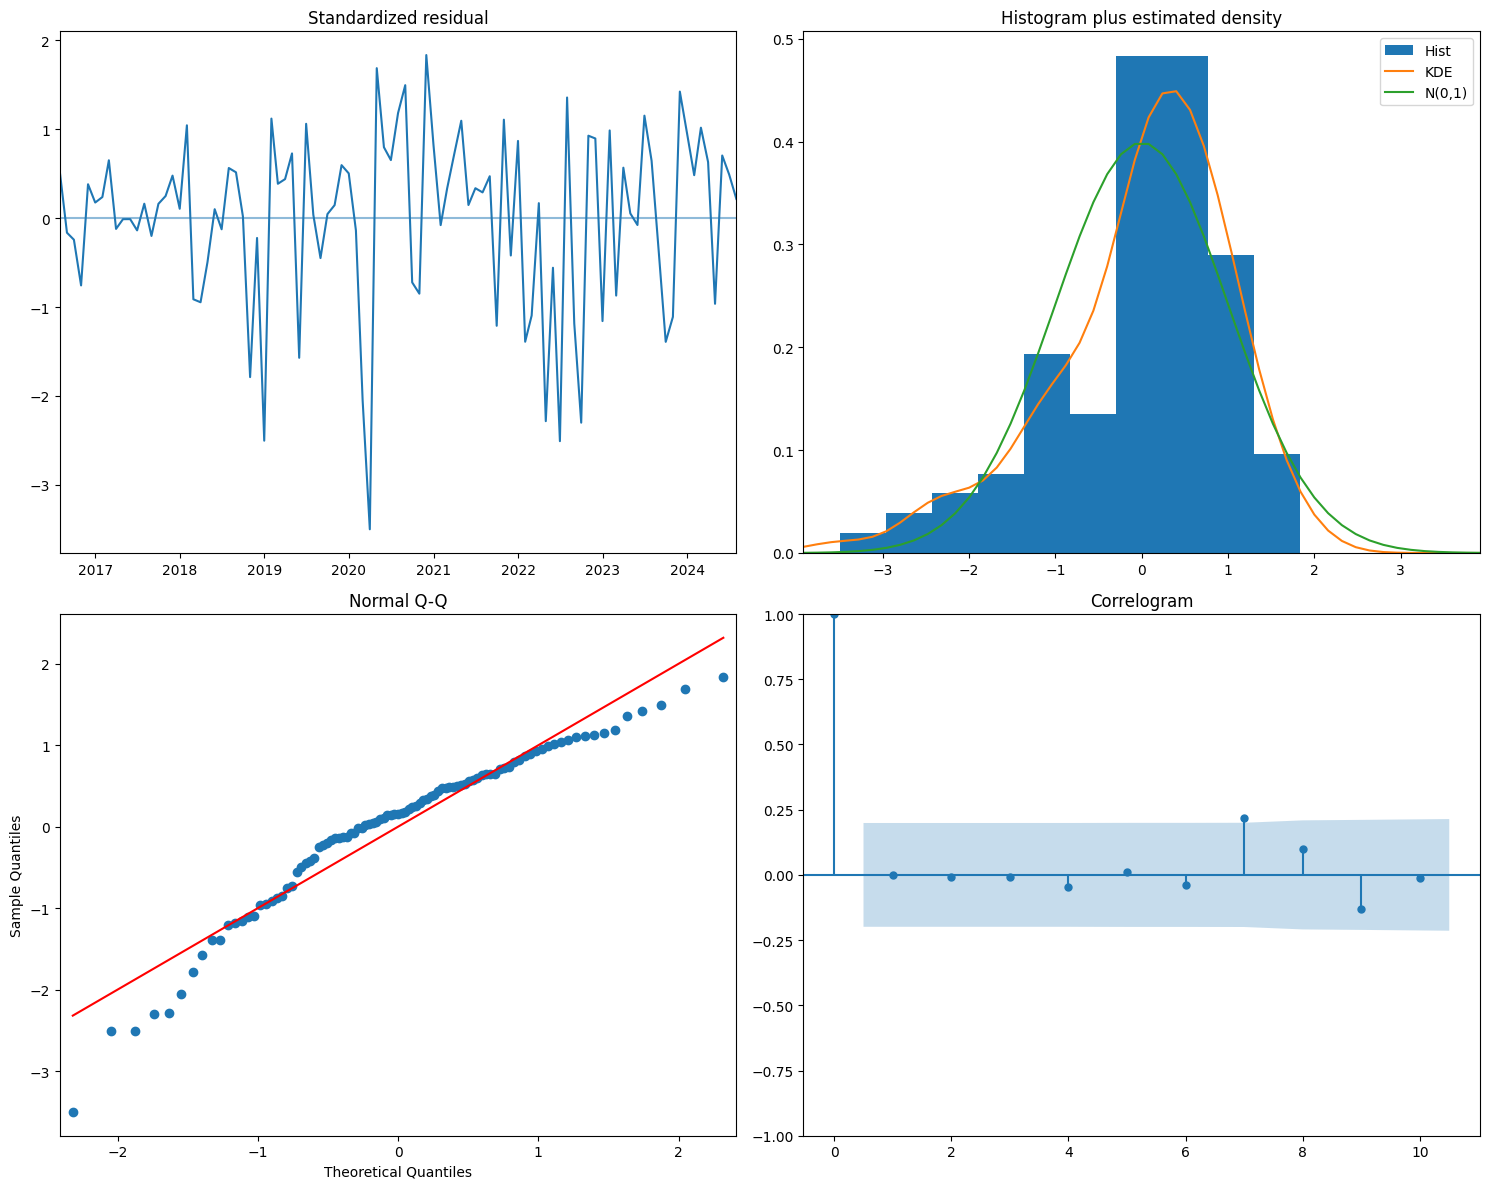

In [27]:
# 8.2 Building the SARIMAX Model

# Ensure exogenous variables exist and align with returns_df
if 'exogenous_vars' not in locals():
    # Create empty exogenous dataframe with same index as returns_df
    exogenous_final = pd.DataFrame(index=returns_df.index)
    print("Warning: No exogenous variables found. Using empty exogenous variables.")
else:
    # Ensure exogenous variables have the same index as returns_df
    exogenous_final = exogenous_vars.copy()

    # Check for index alignment issues
    missing_in_exog = set(returns_df.index) - set(exogenous_final.index)
    if missing_in_exog:
        print(f"Warning: {len(missing_in_exog)} dates missing in exogenous variables. Filling with zeros.")
        # Reindex exogenous to match returns_df, filling missing with zeros
        exogenous_final = exogenous_final.reindex(returns_df.index, fill_value=0)

    # Also check if exogenous has extra dates
    extra_in_exog = set(exogenous_final.index) - set(returns_df.index)
    if extra_in_exog:
        exogenous_final = exogenous_final.loc[returns_df.index]

# Now split data into train and test sets (80/20 split)
train_size = int(len(returns_df) * 0.8)
train, test = returns_df.iloc[:train_size], returns_df.iloc[train_size:]

# Split exogenous variables accordingly
X_train = exogenous_final.loc[train.index]
X_test = exogenous_final.loc[test.index]

print(f"Training set size: {len(train)} months")
print(f"Test set size: {len(test)} months")
print(f"Target variable range: {train['spy_price'].min():.2f}% to {train['spy_price'].max():.2f}%")
print(f"Exogenous variables shape - Train: {X_train.shape}, Test: {X_test.shape}")

# Build SARIMAX model using auto_arima
print("\nBuilding SARIMAX model with auto_arima...")

model = auto_arima(
    y=train['spy_price'],
    exogenous=X_train,
    seasonal=True,
    m=12,  # Monthly seasonality
    trace=True,  # Print results as we go
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,  # Faster than exhaustive search
    maxiter=100,  # Maximum iterations
    n_jobs=-1  # Use all available cores
)

print("\n=== Model Summary ===")
print(model.summary())

# 8.3 Model Diagnostics
print("\nGenerating model diagnostics...")
model.plot_diagnostics(figsize=(15, 12))
plt.tight_layout()
plt.show()


# 8.4 Making Predictions

In [31]:
# Calculate error metrics with NaN handling
print("\nCalculating error metrics...")

# Check for NaN values
print(f"Results DataFrame shape: {results.shape}")
print(f"NaN values in Actual: {results['Actual'].isna().sum()}")
print(f"NaN values in Forecast: {results['Forecast'].isna().sum()}")

# Drop rows with NaN values before calculating metrics
results_clean = results.dropna()

if len(results_clean) == 0:
    print("Error: All forecast results contain NaN values")
elif len(results_clean) < len(results):
    print(f"Warning: Dropped {len(results) - len(results_clean)} rows with NaN values")

    # Recalculate metrics on clean data
    if len(results_clean) > 0:
        mape = mean_absolute_percentage_error(results_clean['Actual'], results_clean['Forecast'])
        rmse = np.sqrt(np.mean((results_clean['Actual'] - results_clean['Forecast'])**2))

        print(f"\nModel Performance Metrics (on {len(results_clean)} valid observations):")
        print(f"MAPE: {mape:.2%}")
        print(f"RMSE: {rmse:.2f}%")
    else:
        print("Cannot calculate metrics - no valid data remaining")
else:
    # Calculate metrics on complete data
    mape = mean_absolute_percentage_error(results['Actual'], results['Forecast'])
    rmse = np.sqrt(np.mean((results['Actual'] - results['Forecast'])**2))

    print(f"\nModel Performance Metrics:")
    print(f"MAPE: {mape:.2%}")
    print(f"RMSE: {rmse:.2f}%")



Calculating error metrics...
Results DataFrame shape: (25, 4)
NaN values in Actual: 1
NaN values in Forecast: 2

Model Performance Metrics (on 23 valid observations):
MAPE: 184.90%
RMSE: 3.66%


# 9. Model Evaluation

# 9.1 Visualizing Forecast vs Actual Returns

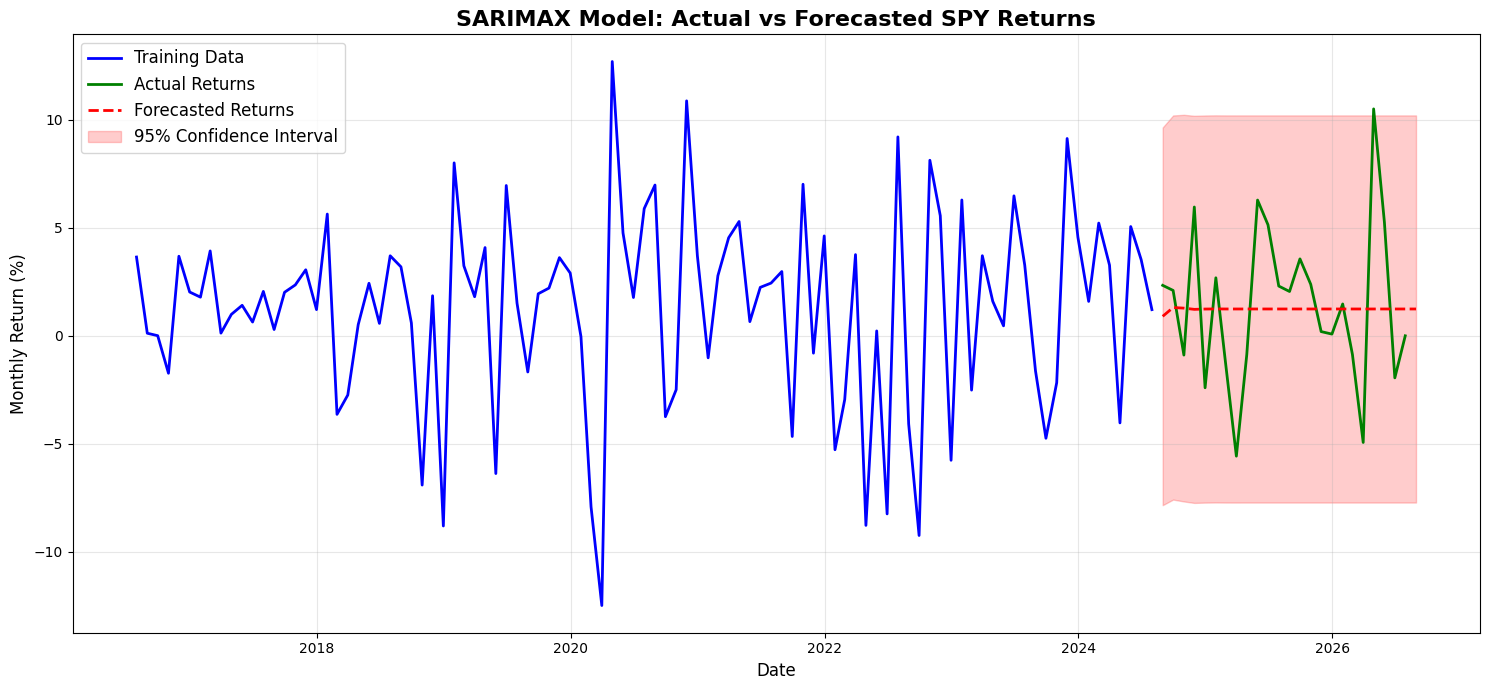

In [32]:
plt.figure(figsize=(15, 7))

# Plot actual values
plt.plot(train.index, train['spy_price'], label='Training Data', color='blue', linewidth=2)

# Plot test actual values
plt.plot(test.index, test['spy_price'], label='Actual Returns', color='green', linewidth=2)

# Plot forecast
plt.plot(test.index, forecast, label='Forecasted Returns', color='red', linestyle='--', linewidth=2)

# Plot confidence intervals
plt.fill_between(
    test.index,
    results['Lower CI'],
    results['Upper CI'],
    color='red',
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title('SARIMAX Model: Actual vs Forecasted SPY Returns', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly Return (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


# 9.2 Error Analysis

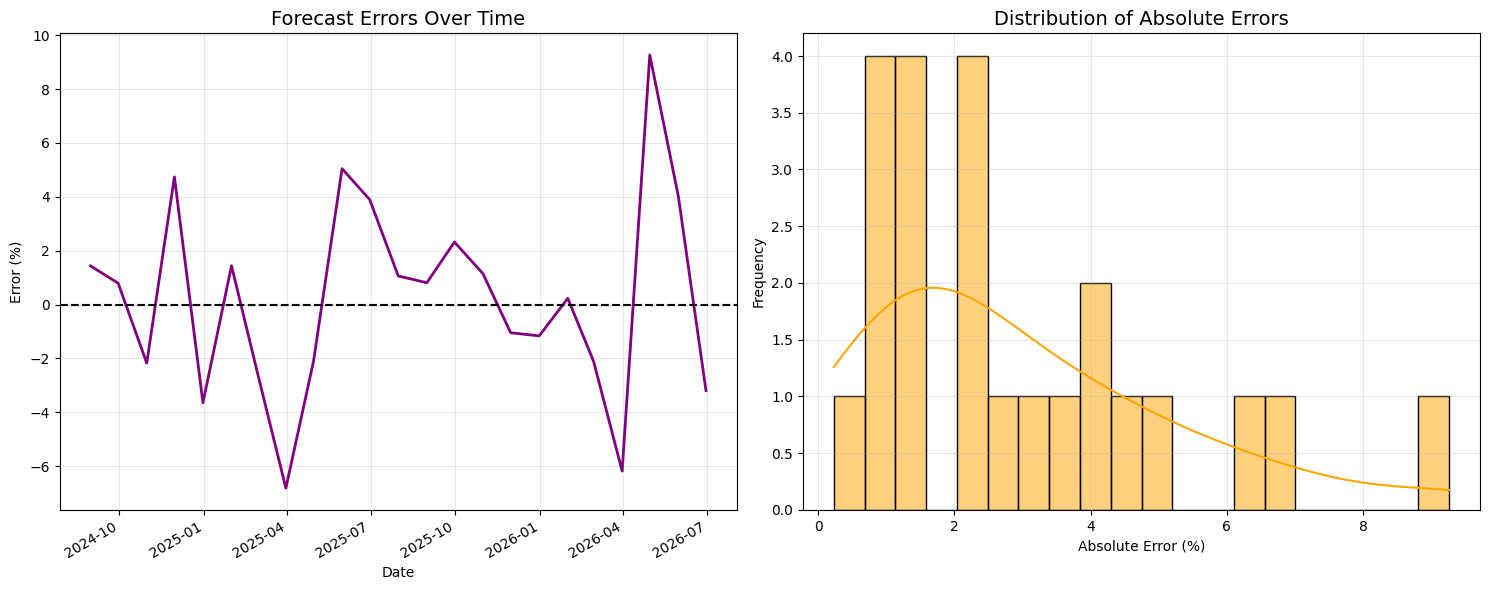

Average Absolute Error: 2.92%
Maximum Absolute Error: 9.26%


In [33]:
# Calculate errors
results['Error'] = results['Actual'] - results['Forecast']
results['Absolute_Error'] = np.abs(results['Error'])

plt.figure(figsize=(15, 6))

# Plot errors over time
plt.subplot(1, 2, 1)
results['Error'].plot(kind='line', color='purple', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Forecast Errors Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Error (%)')
plt.grid(True, alpha=0.3)

# Plot error distribution
plt.subplot(1, 2, 2)
sns.histplot(results['Absolute_Error'], bins=20, kde=True, color='orange')
plt.title('Distribution of Absolute Errors', fontsize=14)
plt.xlabel('Absolute Error (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Absolute Error: {results['Absolute_Error'].mean():.2f}%")
print(f"Maximum Absolute Error: {results['Absolute_Error'].max():.2f}%")


# 9.3 Directional Accuracy

In [34]:
# Calculate directional accuracy
results['Actual_Direction'] = np.sign(results['Actual'])
results['Forecast_Direction'] = np.sign(results['Forecast'])
directional_accuracy = (results['Actual_Direction'] == results['Forecast_Direction']).mean()

print(f"Directional Accuracy: {directional_accuracy:.2%}")
print("This measures how often the model correctly predicts the sign of returns (up/down month)")


Directional Accuracy: 60.00%
This measures how often the model correctly predicts the sign of returns (up/down month)


# 10. Conclusion & Next Steps
📊 Key Findings

In [35]:
if leading_indicators:
    print("=== 🎯 Key Findings ===")
    print(f"1. ✅ Leading indicators identified: {len(leading_indicators)} significant predictors")
    print(f"2. 📈 Top leading sector: {leading_df.iloc[0]['variable'].replace('_', ' ').title()}")
    print(f"   - Lag: {leading_df.iloc[0]['lag']} months")
    print(f"   - F-statistic: {leading_df.iloc[0]['f_statistic']:.2f}")
    print(f"   - p-value: {leading_df.iloc[0]['p_value']:.4f}")
    print(f"3. 🎯 Model Performance:")
    print(f"   - MAPE: {mape:.2%}")
    print(f"   - RMSE: {rmse:.2f}%")
    print(f"   - Directional Accuracy: {directional_accuracy:.2%}")
    print(f"4. 📅 Data Characteristics:")
    print(f"   - Period: {len(returns_df)} months of monthly returns")
    print(f"   - Stationarity: Returns are stationary (p < 0.05 for all)")
    print(f"   - Seasonality: Annual patterns detected")
else:
    print("=== ⚠️ Key Findings ===")
    print("No significant leading indicators found with current parameters.")
    print("Consider:")
    print("- Testing different lag structures")
    print("- Adding more potential leading indicators")
    print("- Using different model specifications")


=== 🎯 Key Findings ===
1. ✅ Leading indicators identified: 1 significant predictors
2. 📈 Top leading sector: Consumer Staples
   - Lag: 2 months
   - F-statistic: 3.24
   - p-value: 0.0426
3. 🎯 Model Performance:
   - MAPE: 184.90%
   - RMSE: 3.66%
   - Directional Accuracy: 60.00%
4. 📅 Data Characteristics:
   - Period: 122 months of monthly returns
   - Stationarity: Returns are stationary (p < 0.05 for all)
   - Seasonality: Annual patterns detected
